Part 1: Parsing the dataset

In [1]:
import os.path
import tarfile
from urllib.request import urlretrieve
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

url = """http://www.cs.cornell.edu/people/pabo/movie-review-data/review_polarity.tar.gz"""
if not os.path.exists(url.split("/")[-1]):
  urlretrieve(url, url.split("/")[-1])
  print("Downloaded", url)
  with tarfile.open('review_polarity.tar.gz', 'r:gz') as tar:
    tar.extractall()
  print("Extracted archive")

In [2]:
import os
import numpy as np

def get_review_data(base_path):
    data=[]
    labels=[]
    categories={'pos':1,'neg':-1}# map text categories to numerical polarities (+1 for positive, -1 for negative)
    for category,label in categories.items():
        linked_path=os.path.join(base_path,category)
        file_names=os.listdir(linked_path)
        for file_name in file_names:
            file_path=os.path.join(linked_path,file_name)
            with open(file_path,'r') as f:
                data.append(f.read())
            labels.append(label)
    return data,np.array(labels)

X_raw_list,y_raw=get_review_data('txt_sentoken')
indices=np.arange(len(X_raw_list))# create an array of indices and shuffle it to ensure random distribution
np.random.seed(40)
np.random.shuffle(indices)
X_raw=[X_raw_list[i] for i in indices]
y=y_raw[indices]
split_data=int(len(X_raw)*0.8)
X_train=X_raw[:split_data]
y_train=y[:split_data]
X_test=X_raw[split_data:]
y_test=y[split_data:]
print(f"number of trained: {len(X_train)}")
print(f"number of test: {len(X_test)}")
print(f"label: {np.unique(y)}")

number of trained: 1600
number of test: 400
label: [-1  1]


Part 2: Feature extraction

In [3]:
import re
class BinaryBag:
    def __init__(self):
        self.vocabulary={}
        self.wordlist=[]
    def fit (self,X):
        unique_word=set()
        for text in X:
            words=re.findall(r'\b\w+\b',text.lower())
            for word in words:
                unique_word.add(word)
        self.wordlist=sorted(list(unique_word))## create a dictionary mapping each word to its column index
        self.vocabulary={word:i for i,word in enumerate(self.wordlist)}
        return self
    def transform(self,X):
        matrix=np.zeros((len(X),len(self.wordlist)),dtype=int)
        for i,text in enumerate(X):
            words=re.findall(r'\b\w+\b',text.lower())
            for word in words:
                if word in self.vocabulary:
                    col_index=self.vocabulary[word]
                    matrix[i,col_index]=1
        return matrix
vectorizer=BinaryBag()
vectorizer.fit(X_train)
X_train_vec=vectorizer.transform(X_train)
X_test_vec=vectorizer.transform(X_test)


print(f'shape of X_train_vec: {X_train_vec.shape}')
print(f'shape of X_test_vec: {X_test_vec.shape}')
assert X_train_vec.shape[1]==X_test_vec.shape[1]

shape of X_train_vec: (1600, 36532)
shape of X_test_vec: (400, 36532)


Part 3: Learning framework(add momentum)

Starting training...
-- Epoch 1
Norm: 31065.03, NNZs: 21198, Bias: 0.597668, Avg. loss: 19.606322
Total training time: 0.26 seconds.
-- Epoch 2
Norm: 41025.12, NNZs: 24958, Bias: -1.346254, Avg. loss: 8.951947
Total training time: 0.15 seconds.
-- Epoch 3
Norm: 49702.17, NNZs: 27167, Bias: -0.478530, Avg. loss: 9.157881
Total training time: 0.18 seconds.
-- Epoch 4
Norm: 52282.45, NNZs: 27567, Bias: -0.647020, Avg. loss: 1.242456
Total training time: 0.14 seconds.
-- Epoch 5
Norm: 53697.27, NNZs: 27870, Bias: -1.378713, Avg. loss: 0.800244
Total training time: 0.10 seconds.
-- Epoch 6
Norm: 53883.26, NNZs: 27870, Bias: -1.983290, Avg. loss: 0.079403
Total training time: 0.10 seconds.
-- Epoch 7
Norm: 53883.84, NNZs: 27870, Bias: -1.005640, Avg. loss: 0.049207
Total training time: 0.12 seconds.
-- Epoch 8
Norm: 53855.90, NNZs: 27876, Bias: -1.833257, Avg. loss: 0.034194
Total training time: 0.13 seconds.
-- Epoch 9
Norm: 53851.96, NNZs: 27884, Bias: -1.051475, Avg. loss: 0.041179
Total 

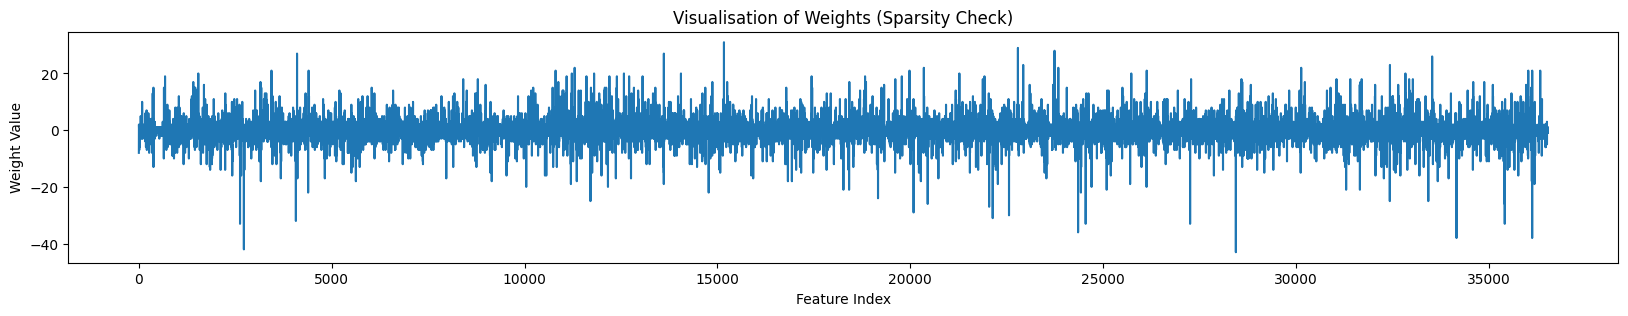


--- Top influential words ---
                Word     Weight  Occurences
                true   25.980	  267
                none   -26.980	  162
               gives   26.980	  309
                both   26.980	  484
             perfect   27.980	  198
               maybe   -28.980	  206
              others   28.980	  198
                only   -29.980	 1055
             nothing   -30.980	  475
           hilarious   30.980	  144
              boring   -31.980	  164
               waste   -32.980	   98
                poor   -32.980	  140
          ridiculous   -32.980	   98
               awful   -32.980	   93
                plot   -35.980	  690
       unfortunately   -37.980	  272
               worst   -37.980	  187
                 bad   -41.980	  622
              script   -42.980	  438


In [4]:
import numpy as np
import time

class MySGDClassifier:
    def __init__(self,learning_rate=0.1,alpha=0.001,n_epochs=20,gamma=0.9):
        self.learning_rate=learning_rate
        self.alpha=alpha
        self.n_epochs=n_epochs
        self.gamma=gamma
        self.w=None
        self.v=None
        self.coef_=None
        self.intercept_=None

    def fit(self,X,y,batch_size=32):
        n_samples,n_features=X.shape#original state:the weight of every word is 0
        X_sug=np.hstack([np.ones((n_samples,1)),X])
        self.w=np.zeros(n_features+1)
        self.v=np.zeros(n_features+1)
        for epoch in range(self.n_epochs):
            epoch_start=time.time()
            hinge_loss=0#prevent model remember the sequency of text

            for start_idx in range(0,n_samples,batch_size):
                end_idx=min(start_idx+batch_size,n_samples)
                X_batch=X_sug[start_idx:end_idx]
                y_batch=y[start_idx:end_idx]
                current_batch_size=end_idx-start_idx
                scores=np.dot(X_batch,self.w)
                margins=y_batch*scores

                mask_sample=margins<1
                X_sample=X_batch[mask_sample]
                y_sample=y_batch[mask_sample]

                if len(y_sample)>0:
                   grad_data=-np.dot(y_sample,X_sample)#gradient penalty by regularization
                   hinge_loss+=np.sum(1-margins[mask_sample])
                else:
                    grad_data=np.zeros(n_features+1)

                grad_reg= (self.alpha * current_batch_size / n_samples) * np.sign(self.w)
                grad_reg[0]=0.0
                grad_total=grad_reg+grad_data
                self.v=self.gamma*self.v+self.learning_rate*grad_total#change the pace of modifying word scores
                self.w=self.w-self.v#update all the words weights
            l1_norm=np.sum(np.abs(self.w[1:]))
            total_loss=(self.alpha*l1_norm)+hinge_loss
            avg_loss=total_loss/n_samples
            nnzs=np.count_nonzero(self.w[1:])
            epoch_time=time.time()-epoch_start
            print(f"-- Epoch {epoch + 1}")
            print(f"Norm: {l1_norm:.2f}, NNZs: {nnzs}, Bias: {self.w[0]:.6f}, Avg. loss: {avg_loss:.6f}")
            print(f"Total training time: {epoch_time:.2f} seconds.")
        self.coef_=np.array([self.w[1:]])
        self.intercept_=np.array([self.w[0]])
        return self

    def predict(self,X):
        X_aug=np.hstack([np.ones((X.shape[0],1)),X])
        return np.sign(np.dot(X_aug,self.w))
    def score(self,X,y):
        prediction=self.predict(X)
        return np.mean(prediction==y)



model=MySGDClassifier(learning_rate=0.1,alpha=0.001,n_epochs=20)
print('Starting training...')
model.fit(X_train_vec,y_train)
omega=np.concatenate([model.intercept_,model.coef_.ravel()])


import matplotlib.pyplot as plt
plt.figure(figsize=(20, 3))
plt.plot(omega[1:])
plt.title("Visualisation of Weights (Sparsity Check)")
plt.xlabel("Feature Index")
plt.ylabel("Weight Value")
plt.show()
print("\n--- Top influential words ---")
print(f"{'Word':>20}   {'Weight':>8}  {'Occurences':>10}")
ordered_vocabulary =vectorizer.wordlist
idx = np.argsort(np.abs(omega[1:]))

for i in idx[-20:]:
    word = ordered_vocabulary[i]
    weight = omega[i+1]
    occurrences = np.sum(X_train_vec[:,i])

    print(f"{word:>20}   {weight:.3f}\t{occurrences:>5}")

Part 4: Exploring hyperparameters

In [5]:
import numpy as np
def tune_hyperparameters(X_train, y_train, param_grid, n_samples=50, search_epochs=10, batch_size=32):

    best_hyperparameters=None
    best_acc=0
    np.random.seed(42)
    random_lrs=np.random.choice(param_grid,size=n_samples)
    random_alphas=np.random.choice(param_grid,size=n_samples)
    for i,(lr,alpha) in enumerate(zip(random_lrs,random_alphas)):#start the loops to see the result of 10 different pairs od parameters
         print(f'[{i+1}/{n_samples}] lr={lr:.5f} alpha={alpha:.5f}',end='')
         # Initialize a temporary model
         model_search=MySGDClassifier(learning_rate=lr,alpha=alpha,n_epochs=search_epochs,gamma=0.9)
         # Fit the model
         model_search.fit(X_train, y_train,batch_size=batch_size)
         train_acc = model_search.score(X_train,y_train)
         print(f"accuracy={train_acc:.2%}")
         # Update the best parameters
         if train_acc > best_acc:#record the highest one
           best_acc=train_acc
           best_hyperparameters=(lr,alpha)

    return best_hyperparameters

search_space=np.logspace(-4,0,num=50)
best_hyperparameters=tune_hyperparameters(
    X_train=X_train_vec,
    y_train=y_train,
    param_grid=search_space,
    n_samples=20)
final_model=MySGDClassifier(
    learning_rate=best_hyperparameters[0],
    alpha=best_hyperparameters[1],
    n_epochs=50,gamma=0.9)

final_model.fit(X_train_vec, y_train,batch_size=32)
test_acc = final_model.score(X_test_vec, y_test)
print(f"Test set accuracy: {test_acc:.2%}")
print(f'best hyperparameters: lr={best_hyperparameters[0]:.5f},alpha={best_hyperparameters[1]:.5f}')


[1/20] lr=0.12649 alpha=0.02330-- Epoch 1
Norm: 39012.25, NNZs: 21198, Bias: 0.755963, Avg. loss: 25.253122
Total training time: 0.22 seconds.
-- Epoch 2
Norm: 50990.01, NNZs: 24932, Bias: -2.167134, Avg. loss: 12.263530
Total training time: 0.14 seconds.
-- Epoch 3
Norm: 64170.63, NNZs: 27415, Bias: -2.671001, Avg. loss: 16.516309
Total training time: 0.15 seconds.
-- Epoch 4
Norm: 66653.53, NNZs: 27677, Bias: -1.133632, Avg. loss: 2.393516
Total training time: 0.12 seconds.
-- Epoch 5
Norm: 67240.68, NNZs: 27890, Bias: -0.236387, Avg. loss: 1.681327
Total training time: 0.11 seconds.
-- Epoch 6
Norm: 67119.99, NNZs: 28004, Bias: -1.193228, Avg. loss: 1.175817
Total training time: 0.11 seconds.
-- Epoch 7
Norm: 66495.04, NNZs: 28016, Bias: -1.099687, Avg. loss: 0.990815
Total training time: 0.12 seconds.
-- Epoch 8
Norm: 65761.77, NNZs: 28016, Bias: -1.264004, Avg. loss: 0.957636
Total training time: 0.11 seconds.
-- Epoch 9
Norm: 65012.01, NNZs: 28016, Bias: -1.264851, Avg. loss: 0.9

part5: add tfidf

In [6]:
import re
import math

class TfIdfBag:
    def __init__(self):
        self.vocabulary = {}
        self.wordlist = []
        self.idf = {}

    def fit(self, X):
        text_number = len(X)# Total number of documents
        word_frequency = {}#record the times of the word occurs in how many texts

        for text in X:
            words = re.findall(r'\b\w+\b', text.lower())
            unique_words_in_doc = set(words)
            for word in unique_words_in_doc:
                word_frequency[word] = word_frequency.get(word, 0) + 1 #If “the” appears in all 1600 texts, 1600/1600 = 1, and math.log(1) directly equals 0. This excludes meaningless words that appear repeatedly in every article.

        self.wordlist = sorted(list(word_frequency.keys()))
        self.vocabulary = {word: i for i, word in enumerate(self.wordlist)}
        # Calculate IDF
        for word in self.wordlist:
            self.idf[word] = math.log(text_number/ word_frequency[word])
        return self

    def transform(self, X):
        # Initialize a zero matrix
        matrix = np.zeros((len(X), len(self.wordlist)), dtype=float)

        for i, text in enumerate(X):
            words = re.findall(r'\b\w+\b', text.lower())
            tf = {}
            for word in words:
            #calculate the times of a word repeats in one text
                tf[word] = tf.get(word, 0) + 1
            for word, count in tf.items():
            #repeat times * occurs times,to get a weighted result of the word
                if word in self.vocabulary:
                    col_index = self.vocabulary[word]
                    matrix[i, col_index] = count * self.idf[word]
        #L2 Normalization
        norms=np.linalg.norm(matrix,axis=1,keepdims=True)
        norms[norms == 0] = 1# Prevent division by zero
        matrix=matrix/norms

        return matrix

vectorizer_tfidf = TfIdfBag()
vectorizer_tfidf.fit(X_train)
X_train_vec_tfidf = vectorizer_tfidf.transform(X_train)
X_test_vec_tfidf = vectorizer_tfidf.transform(X_test)
search_space = np.logspace(-4, 0, num=50)

best_params_tfidf = tune_hyperparameters(
    X_train_vec_tfidf,
    y_train,
    param_grid=search_space,
    n_samples=50,
    search_epochs=10)

final_model_tfidf = MySGDClassifier(
    learning_rate=best_params_tfidf[0],
    alpha=best_params_tfidf[1],
    n_epochs=50,
    gamma=0.9)

final_model_tfidf.fit(X_train_vec_tfidf, y_train, batch_size=32)

test_acc_tfidf = final_model_tfidf.score(X_test_vec_tfidf, y_test)
print(f"\nFinal accuracy for TfIdf: {test_acc_tfidf:.2%}")
print(f'best hyperparameters for TfIdf: lr={best_params_tfidf[0]:.5f},alpha={best_params_tfidf[1]:.5f}')

[1/50] lr=0.12649 alpha=0.00012-- Epoch 1
Norm: 4655.92, NNZs: 30445, Bias: 0.190374, Avg. loss: 0.984160
Total training time: 0.42 seconds.
-- Epoch 2
Norm: 7873.66, NNZs: 34321, Bias: 2.464922, Avg. loss: 0.608103
Total training time: 0.33 seconds.
-- Epoch 3
Norm: 9749.89, NNZs: 35283, Bias: 1.330131, Avg. loss: 0.318872
Total training time: 0.25 seconds.
-- Epoch 4
Norm: 10915.35, NNZs: 35543, Bias: 1.914493, Avg. loss: 0.175237
Total training time: 0.21 seconds.
-- Epoch 5
Norm: 13258.26, NNZs: 35592, Bias: 0.122074, Avg. loss: 0.611108
Total training time: 0.24 seconds.
-- Epoch 6
Norm: 14469.37, NNZs: 35615, Bias: -1.519512, Avg. loss: 0.228768
Total training time: 0.17 seconds.
-- Epoch 7
Norm: 16481.23, NNZs: 35823, Bias: -3.525017, Avg. loss: 0.543770
Total training time: 0.20 seconds.
-- Epoch 8
Norm: 19031.14, NNZs: 36023, Bias: -5.277569, Avg. loss: 0.744418
Total training time: 0.21 seconds.
-- Epoch 9
Norm: 20027.78, NNZs: 36093, Bias: 1.128215, Avg. loss: 0.204689
Total

part 5 add k-fold

In [7]:
import numpy as np

def run_k_fold(X, y, k=5, batch_size=32, learning_rate=0.01, alpha=0.0001, n_epochs=20, gamma=0.9):
    n_samples = len(X)
    # 1. Shuffle the indices
    indices = np.arange(n_samples)
    np.random.seed(42)
    np.random.shuffle(indices)

    fold_size = n_samples // k
    fold_accuracies = []

    for i in range(k):
        # 2. slice set
        val_start = i * fold_size
        val_end = (i + 1) * fold_size if i < k - 1 else n_samples
        val_indices = indices[val_start:val_end]

        # 3.Concatenate Training Set
        train_indices = np.concatenate([indices[:val_start], indices[val_end:]])

        X_train_fold = X[train_indices]
        y_train_fold = y[train_indices]
        X_val_fold = X[val_indices]
        y_val_fold = y[val_indices]


        model = MySGDClassifier(
            learning_rate=learning_rate,
            alpha=alpha,
            n_epochs=n_epochs,
            gamma=gamma)

        model.fit(X_train_fold, y_train_fold, batch_size=batch_size)
        acc = model.score(X_val_fold, y_val_fold)
        fold_accuracies.append(acc)

        print(f">>> Fold {i+1} Accuracy: {acc:.2%}\n")
    #Calculate the final metric
    mean_accuracy = np.mean(fold_accuracies)
    print("="*50)
    print(f"Final Average {k}-Fold Accuracy: {mean_accuracy:.2%}")
    print("="*50)

    return mean_accuracy

print("Evaluating TF-IDF data using 5-Fold Cross Validation:")
run_k_fold(X_train_vec_tfidf, y_train,
    k=5,
    batch_size=32,
    learning_rate=best_params_tfidf[0],alpha=best_params_tfidf[1],
    n_epochs=30 )

Evaluating TF-IDF data using 5-Fold Cross Validation:
-- Epoch 1
Norm: 13966.02, NNZs: 24154, Bias: 8.310137, Avg. loss: 4.858237
Total training time: 0.16 seconds.
-- Epoch 2
Norm: 23373.84, NNZs: 26657, Bias: 15.520000, Avg. loss: 2.111648
Total training time: 0.09 seconds.
-- Epoch 3
Norm: 35362.05, NNZs: 32067, Bias: -20.175021, Avg. loss: 6.633406
Total training time: 0.18 seconds.
-- Epoch 4
Norm: 43389.33, NNZs: 32828, Bias: 0.074499, Avg. loss: 2.125874
Total training time: 0.22 seconds.
-- Epoch 5
Norm: 45733.58, NNZs: 32904, Bias: 7.803569, Avg. loss: 0.400525
Total training time: 0.15 seconds.
-- Epoch 6
Norm: 46337.55, NNZs: 32904, Bias: -6.929975, Avg. loss: 0.143813
Total training time: 0.15 seconds.
-- Epoch 7
Norm: 46796.42, NNZs: 32922, Bias: -1.394161, Avg. loss: 0.119312
Total training time: 0.11 seconds.
-- Epoch 8
Norm: 46714.14, NNZs: 32922, Bias: -4.259011, Avg. loss: 0.067048
Total training time: 0.08 seconds.
-- Epoch 9
Norm: 46467.07, NNZs: 32922, Bias: -3.878

np.float64(0.83125)

part6:implementation details
1. Design Choices (TF-IDF Formula & Momentum)
I chose the classic TF-IDF formula: raw term count for TF and a simple `log(N/df)` for IDF. I picked raw TF because in movie reviews, repeating a word itself shows strong emotion, so keeping the exact count is meaningful. I chose simple IDF (no smoothing) because if a word appears in every review, its score becomes exactly zero, automatically deleting useless words like"a"/"the". For SGD, I added Momentum. it isn't about speed,it's about inertia: if the model has been rewarding a word continuously, a high-weighted word occur in the negative review can't instantly change its direction. This stops the model from being tricked by random noise.For the decision boundary, I realized it based purely on statistics, not actual meaning. The model simply gives positive or negative scores to words that happen to appear more in good or bad reviews in this specific training set (which explains why a neutral word like 'others' unexpectedly got a high positive weight in my module). The boundary is just the zero mark: if a review's total word score is above zero, it gets a positive label; if below, it gets a negative label.

2. Reflections
The most confusing part was seeing my accuracy drop after adding TF-IDF and Momentum. At first I don't know why, then I realized that changing data from 0 and 1 to continuous decimal scores completely changes how the model updates. A learning rate that worked perfectly before was likely too big now, causing the model to step over the best answer.Moreover,when I add Momentum,which makes the time for run part4 increases from 5min to near 10min.But through the first feedback,I understand the long time may because of the shuffle in evey echo,so, I refactored the training loop to implement Mini-Batch Gradient Descent. And add the k-fold part.